In [ ]:
import numpy as np
import tensorflow as tf
import math
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks, optimizers

# Synthetic data (for fast experiment)
x_train = np.random.random((1000, 20))
y_train = np.random.randint(0, 2, (1000,))
x_val = np.random.random((200, 20))
y_val = np.random.randint(0, 2, (200,))

# Base Model
def create_model(lr=0.01):
    model = models.Sequential([
        layers.Input(shape=(20,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy'
    )
    return model


In [ ]:
# Step Decay
def step_decay(epoch):
    initial_lr = 0.01
    drop = 0.5
    epochs_drop = 5
    return float(initial_lr * (drop ** (epoch // epochs_drop)))

# Exponential Decay
def exp_decay(epoch):
    initial_lr = 0.01
    k = 0.1
    return float(initial_lr * np.exp(-k * epoch))

# Adaptive LR
adaptive_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

# Early Stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [ ]:

# Track Learning Rate
class LRHistory(callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        if not hasattr(self, 'lrs'):
            self.lrs = []
        self.lrs.append(float(tf.keras.backend.get_value(self.model.optimizer.learning_rate)))

def train_model(callback_list=None):
    model = create_model()
    lr_track = LRHistory()

    cbs = [lr_track]
    if callback_list:
        cbs += callback_list

    history = model.fit(
        x_train, y_train,
        epochs=20,
        validation_data=(x_val, y_val),
        callbacks=cbs,
        verbose=0
    )

    return history.history['val_loss'], lr_track.lrs



Epoch 5: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.


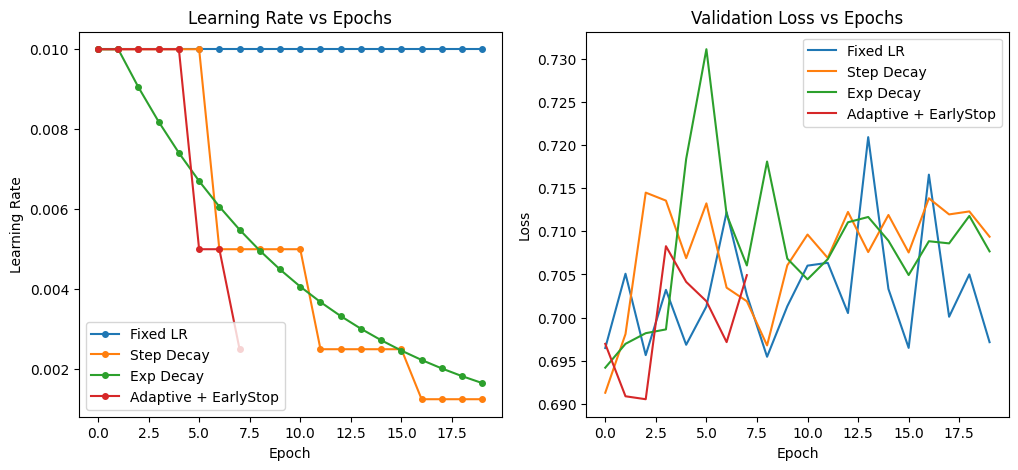

In [ ]:
results = {
    "Fixed LR": train_model(),
    "Step Decay": train_model([callbacks.LearningRateScheduler(step_decay)]),
    "Exp Decay": train_model([callbacks.LearningRateScheduler(exp_decay)]),
    "Adaptive + EarlyStop": train_model([adaptive_lr, early_stop])
}

plt.figure(figsize=(12,5))

# Learning Rate Graph
plt.subplot(1,2,1)
for name,(loss,lrs) in results.items():
    plt.plot(lrs, label=name, marker='o', markersize=4)
plt.title("Learning Rate vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()

# Validation Loss Graph
plt.subplot(1,2,2)
for name,(loss,lrs) in results.items():
    plt.plot(loss,label=name)
plt.title("Validation Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()
